# T and S3 at different thickness

In [35]:
import numpy as np
import matplotlib.pyplot as plt

plot_wl = 0.505

angles = np.linspace(-0.5*np.pi,0.5*np.pi,37)
fo = np.load("0.000pi.npz")
wl = fo["arr_4"]
thickness = fo["arr_5"]
plot_idx = np.argmin(np.abs(wl - plot_wl))

T_img = np.zeros((angles.shape[0],thickness.shape[0]))
S3_img = np.zeros_like(T_img)
S1_img = np.zeros_like(T_img)
for i in range(angles.shape[0]):
    fo = np.load("%.3fpi.npz"%(angles[i]/np.pi))
    T_img[i] = fo["arr_0"][:,plot_idx]
    cur_S = fo["arr_2"]
    S1_img[i] = cur_S[:,plot_idx,1]/cur_S[:,plot_idx,0]
    S3_img[i] = cur_S[:,plot_idx,3]/cur_S[:,plot_idx,0]


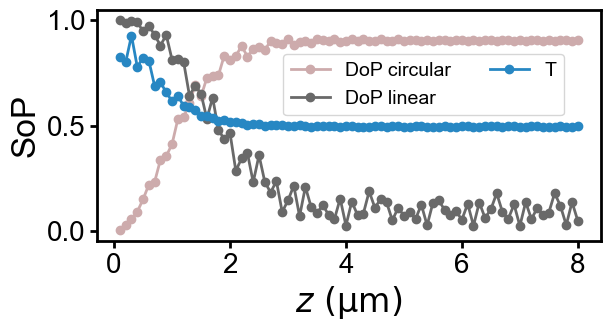

In [36]:
angles = np.linspace(-0.5*np.pi,0.5*np.pi,37)
fo = np.load("0.000pi.npz")
T = fo["arr_0"]
R = fo["arr_1"]
S_T = fo["arr_2"]
S_R = fo["arr_3"]
wl = fo["arr_4"]
thickness = fo["arr_5"]
plot_idx = np.argmin(np.abs(wl - plot_wl))
rl = np.sqrt(np.square(S_T[:,plot_idx,1]/S_T[:,plot_idx,0]) + np.square(S_T[:,plot_idx,2]/S_T[:,plot_idx,0]))
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']

plt.figure(figsize=(6.5, 3))
plt.rcParams['font.sans-serif'] = ['Arial']

plt.plot(thickness,S_T[:,plot_idx,3]/S_T[:,plot_idx,0],"o-",lw=2,c=colors[3],label="DoP circular")
plt.plot(thickness,rl,"o-",lw=2,c=colors[6],label="DoP linear")
plt.plot(thickness,T[:,plot_idx],"o-",lw=2,c=colors[0],label="T")

#plt.ylim(-0.1,1.2)
plt.ylabel("SoP",fontsize=24)
plt.xlabel(r"$z\ (\rm \mu m)$",fontsize=24)
plt.xticks([0,2,4,6,8],fontsize=20)
plt.yticks([0,0.5,1],fontsize=20)
plt.legend(fontsize=14,ncol=2,bbox_to_anchor=(0.35,0.5))


bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./DoP_T.svg",transparent=True,bbox_inches="tight")

plt.show()

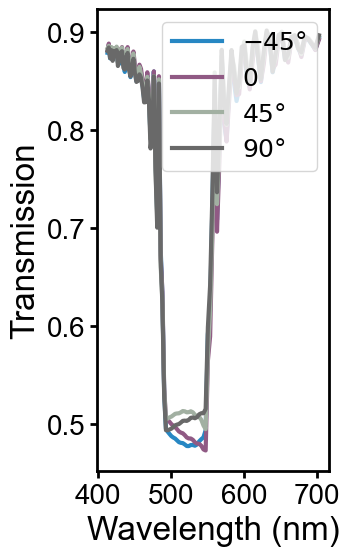

In [61]:
plot_angles = [-0.25,0,0.25,0.5]
plot_thickness = 7
plot_idx = np.argmin(np.abs(thickness - plot_thickness))
labels = [r"$-45\degree$","$0$",r"$45\degree$",r"$90\degree$"]
colors = ["#2787C3", "#5454AA", "#905A84", "#CDABAC", "#A2B0A2", '#778899', '#696969']

plt.figure(figsize=(3, 6))
plt.rcParams['font.sans-serif'] = ['Arial']

for i in range(len(plot_angles)):
    fo = np.load("./%.3fpi.npz"%plot_angles[i])
    T = fo["arr_0"]
    R = fo["arr_1"]
    S_T = fo["arr_2"]
    S_R = fo["arr_3"]
    cur_T = np.mean(T[plot_idx-5:plot_idx+5,:],0)

    plt.plot(wl*1000,cur_T,
             lw=3,label=labels[i],c=colors[i*2])

plt.xticks([400,500,600,700],fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Wavelength (nm)",fontsize=24)
plt.ylabel("Transmission",fontsize=24)
plt.legend(fontsize=18,loc=1)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./T.svg",transparent=True,bbox_inches="tight")

plt.show()

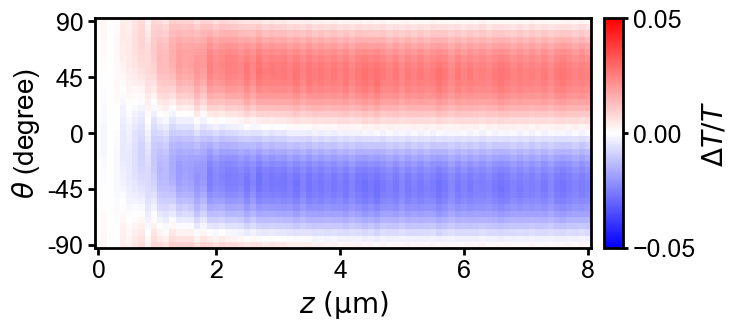

In [38]:
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots() 
plt_img = (T_img-np.mean(T_img,0))/np.mean(T_img,0)
img = ax.imshow(plt_img[::-1],cmap="bwr",vmin=-0.05,vmax=0.05)

ax.set_xticks([0,19,39,59,79],[0,2,4,6,8],fontsize=18)
ax.set_yticks([0,9,18,27,36],["90","45","0","-45","-90"],fontsize=18)
ax.set_xlabel(r"$z\ (\rm \mu m)$",fontsize=20)
ax.set_ylabel(r"$\theta$ (degree)",fontsize=20)

bwidth=2
ax.tick_params(which="major",width=bwidth,length=5)
ax.tick_params(which="minor",width=bwidth,length=3)
tk=fig.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-0.05,0,0.05])
cbar.set_label(r"$\Delta T/T$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)


plt.savefig("./505_T.svg",transparent=True,bbox_inches="tight")
plt.show()

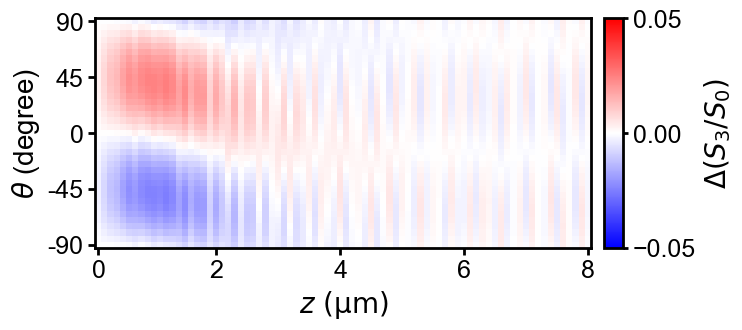

In [39]:
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots() 
plt_img = S3_img-np.mean(S3_img,0)
img = ax.imshow(plt_img[::-1],cmap="bwr",vmin=-0.05,vmax=0.05)

ax.set_xticks([0,19,39,59,79],[0,2,4,6,8],fontsize=18)
ax.set_yticks([0,9,18,27,36],["90","45","0","-45","-90"],fontsize=18)
ax.set_xlabel(r"$z\ (\rm \mu m)$",fontsize=20)
ax.set_ylabel(r"$\theta$ (degree)",fontsize=20)

bwidth=2
ax.tick_params(which="major",width=bwidth,length=5)
ax.tick_params(which="minor",width=bwidth,length=3)
tk=fig.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-0.05,0,0.05])
cbar.set_label(r"$\Delta (S_3/S_0)$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)


plt.savefig("./505_S3.svg",transparent=True,bbox_inches="tight")
plt.show()

In [40]:
plot_wl = 0.540

angles = np.linspace(-0.5*np.pi,0.5*np.pi,37)
fo = np.load("0.000pi.npz")
wl = fo["arr_4"]
thickness = fo["arr_5"]
plot_idx = np.argmin(np.abs(wl - plot_wl))

T_img = np.zeros((angles.shape[0],thickness.shape[0]))
S3_img = np.zeros_like(T_img)
S1_img = np.zeros_like(T_img)
for i in range(angles.shape[0]):
    fo = np.load("%.3fpi.npz"%(angles[i]/np.pi))
    T_img[i] = fo["arr_0"][:,plot_idx]
    cur_S = fo["arr_2"]
    S1_img[i] = cur_S[:,plot_idx,1]/cur_S[:,plot_idx,0]
    S3_img[i] = cur_S[:,plot_idx,3]/cur_S[:,plot_idx,0]


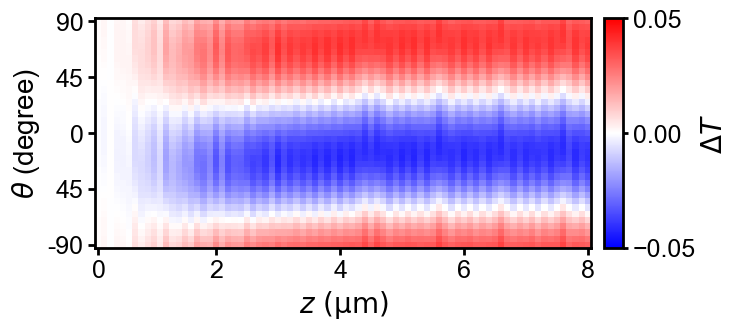

In [41]:
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots() 
plt_img = (T_img-np.mean(T_img,0))/np.mean(T_img,0)
img = ax.imshow(plt_img[::-1],cmap="bwr",vmin=-0.05,vmax=0.05)

ax.set_xticks([0,19,39,59,79],[0,2,4,6,8],fontsize=18)
ax.set_yticks([0,9,18,27,36],["90","45","0","45","-90"],fontsize=18)
ax.set_xlabel(r"$z\ (\rm \mu m)$",fontsize=20)
ax.set_ylabel(r"$\theta$ (degree)",fontsize=20)

bwidth=2
ax.tick_params(which="major",width=bwidth,length=5)
ax.tick_params(which="minor",width=bwidth,length=3)
tk=fig.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-0.05,0,0.05])
cbar.set_label(r"$\Delta T$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)


plt.savefig("./540_T.svg",transparent=True,bbox_inches="tight")
plt.show()

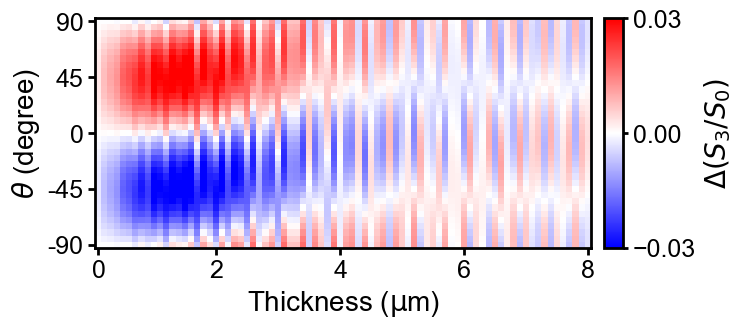

In [42]:
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots()
plt_img = S3_img-np.mean(S3_img,0)
img = ax.imshow(plt_img[::-1],cmap="bwr",vmin=-0.03,vmax=0.03)

ax.set_xticks([0,19,39,59,79],[0,2,4,6,8],fontsize=18)
ax.set_yticks([0,9,18,27,36],["90","45","0","-45","-90"],fontsize=18)
ax.set_xlabel(r"Thickness ($\rm \mu$m)",fontsize=20)
ax.set_ylabel(r"$\theta$ (degree)",fontsize=20)

bwidth=2
ax.tick_params(which="major",width=bwidth,length=5)
ax.tick_params(which="minor",width=bwidth,length=3)
tk=fig.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-0.03,0,0.03])
cbar.set_label(r"$\Delta (S_3/S_0)$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)

plt.savefig("./540_S3.svg",transparent=True,bbox_inches="tight")
plt.show()

In [54]:
plot_wl = 0.495

angles = np.linspace(-0.5*np.pi,0.5*np.pi,37)
fo = np.load("0.000pi.npz")
wl = fo["arr_4"]
thickness = fo["arr_5"]
plot_idx = np.argmin(np.abs(wl - plot_wl))

T_img = np.zeros((angles.shape[0],thickness.shape[0]))
S3_img = np.zeros_like(T_img)
S1_img = np.zeros_like(T_img)
for i in range(angles.shape[0]):
    fo = np.load("%.3fpi.npz"%(angles[i]/np.pi))
    T_img[i] = fo["arr_0"][:,plot_idx]
    cur_S = fo["arr_2"]
    S1_img[i] = cur_S[:,plot_idx,1]/cur_S[:,plot_idx,0]
    S3_img[i] = cur_S[:,plot_idx,3]/cur_S[:,plot_idx,0]

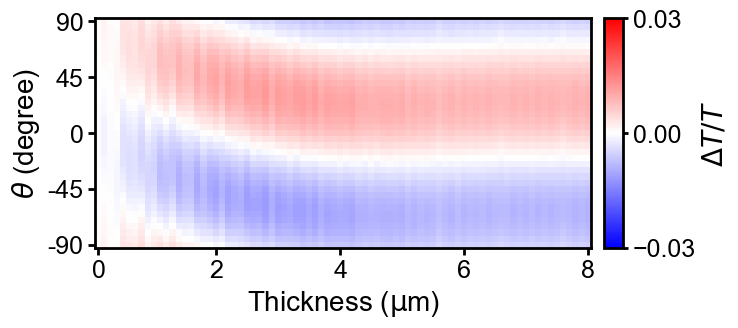

In [55]:
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots() 
plt_img = T_img-np.mean(T_img,0)
img = ax.imshow(plt_img[::-1],cmap="bwr",vmin=-0.03,vmax=0.03)
ax.set_xticks([0,19,39,59,79],[0,2,4,6,8],fontsize=18)
ax.set_yticks([0,9,18,27,36],["90","45","0","-45","-90"],fontsize=18)
ax.set_xlabel(r"Thickness ($\rm \mu$m)",fontsize=20)
ax.set_ylabel(r"$\theta$ (degree)",fontsize=20)

bwidth=2
ax.tick_params(which="major",width=bwidth,length=5)
ax.tick_params(which="minor",width=bwidth,length=3)
tk=fig.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-0.03,0,0.03])
cbar.set_label(r"$\Delta T/T$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)


plt.savefig("./495_T.svg",transparent=True,bbox_inches="tight")
plt.show()

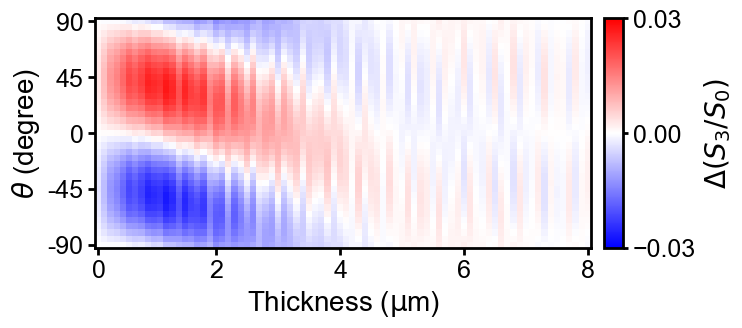

In [56]:
plt.rcParams['font.sans-serif'] = ['Arial']

fig, ax = plt.subplots()
plt_img = S3_img-np.mean(S3_img,0)
img = ax.imshow(plt_img[::-1],cmap="bwr",vmin=-0.03,vmax=0.03)

ax.set_xticks([0,19,39,59,79],[0,2,4,6,8],fontsize=18)
ax.set_yticks([0,9,18,27,36],["90","45","0","-45","-90"],fontsize=18)
ax.set_xlabel(r"Thickness ($\rm \mu$m)",fontsize=20)
ax.set_ylabel(r"$\theta$ (degree)",fontsize=20)

bwidth=2
ax.tick_params(which="major",width=bwidth,length=5)
ax.tick_params(which="minor",width=bwidth,length=3)
tk=fig.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-0.03,0,0.03])
cbar.set_label(r"$\Delta (S_3/S_0)$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)


plt.savefig("./495_S3.svg",transparent=True,bbox_inches="tight")
plt.show()

# T and S3 at different wl

In [46]:
import numpy as np
import matplotlib.pyplot as plt

plot_thickness = 3

angles = np.linspace(-0.5*np.pi,0.5*np.pi,37)
fo = np.load("0.000pi.npz")
wl = fo["arr_4"]
thickness = fo["arr_5"]
plot_idx = np.argmin(np.abs(thickness - plot_thickness))

wl_new = np.linspace(np.min(wl),np.max(wl),wl.shape[0])
T_img = np.zeros((angles.shape[0],wl.shape[0]))
S3_img = np.zeros_like(T_img)
S1_img = np.zeros_like(T_img)
for i in range(angles.shape[0]):
    fo = np.load("%.3fpi.npz"%(angles[i]/np.pi))
    T_img[i] = fo["arr_0"][plot_idx,:]
    T_img[i] = np.interp(wl_new,wl[::-1],T_img[i][::-1])
    cur_S = fo["arr_2"]
    S1_img[i] = cur_S[plot_idx,:,1]/cur_S[plot_idx,:,0]
    S3_img[i] = cur_S[plot_idx,:,3]/cur_S[plot_idx,:,0]


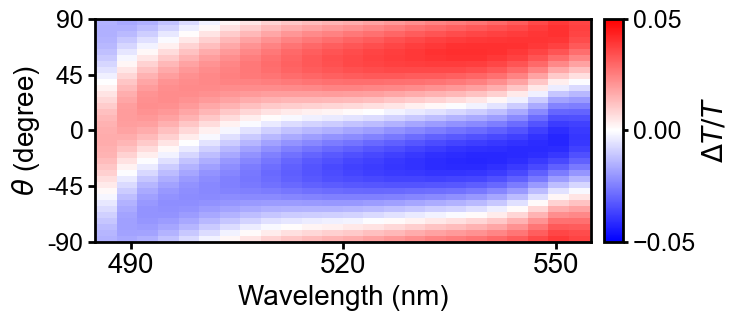

In [47]:
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots()
plt_img = (T_img-np.mean(T_img,0))/np.mean(T_img,0)
img = ax.imshow(plt_img[::-1],
                extent=[wl_new[0]*1000,wl_new[-1]*1000,0.5*np.pi,-0.5*np.pi],
                aspect=10,
                cmap="bwr",
                vmin=-0.05,
                vmax=0.05
               )

plt.xlim(485,555)
ax.set_xticks([490,520,550],[490,520,550],fontsize=20)
ax.set_yticks([-0.5*np.pi,-0.25*np.pi,0,0.25*np.pi,0.5*np.pi],["90","45","0","-45","-90"],fontsize=18)
ax.set_xlabel(r"Wavelength (nm)",fontsize=20)
ax.set_ylabel(r"$\theta$ (degree)",fontsize=20)

bwidth=2
ax.tick_params(which="major",width=bwidth,length=5)
ax.tick_params(which="minor",width=bwidth,length=3)
tk=fig.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-0.05,0,0.05])
cbar.set_label(r"$\Delta T/T$",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)


plt.savefig("./wl_T.svg",transparent=True,bbox_inches="tight")
plt.show()

In [31]:
wl

array([0.7027027 , 0.69775007, 0.69286676, 0.68805132, 0.68330236,
       0.67861851, 0.67399843, 0.66944083, 0.66494446, 0.66050808,
       0.65613051, 0.65181058, 0.64754717, 0.64333917, 0.6391855 ,
       0.63508512, 0.63103702, 0.62704019, 0.62309368, 0.61919654,
       0.61534784, 0.61154669, 0.60779221, 0.60408355, 0.60041987,
       0.59680037, 0.59322425, 0.58969072, 0.58619904, 0.58274847,
       0.57933828, 0.57596778, 0.57263626, 0.56934307, 0.56608753,
       0.56286901, 0.55968689, 0.55654054, 0.55342937, 0.55035279,
       0.54731023, 0.54430112, 0.54132492, 0.53838109, 0.53546911,
       0.53258845, 0.52973863, 0.52691914, 0.52412951, 0.52136925,
       0.51863792, 0.51593506, 0.51326022, 0.51061297, 0.5079929 ,
       0.50539957, 0.50283258, 0.50029155, 0.49777606, 0.49528574,
       0.49282022, 0.49037912, 0.48796209, 0.48556876, 0.4831988 ,
       0.48085186, 0.47852761, 0.47622572, 0.47394587, 0.47168774,
       0.46945103, 0.46723543, 0.46504065, 0.46286639, 0.46071

# Rotation

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def get_rotation(S1,S2):
    # S1 and S2 should be 1D array
    rotation = (S1+1)/2*90
    rotation = np.where(S2>0,rotation,-rotation)
    return rotation

def get_add_angle(r1,r2):
    try_array = np.arange(-4,5)*180
    result = try_array[np.argmin(np.abs(r2+try_array-r1))]
    return result

### Low resolution

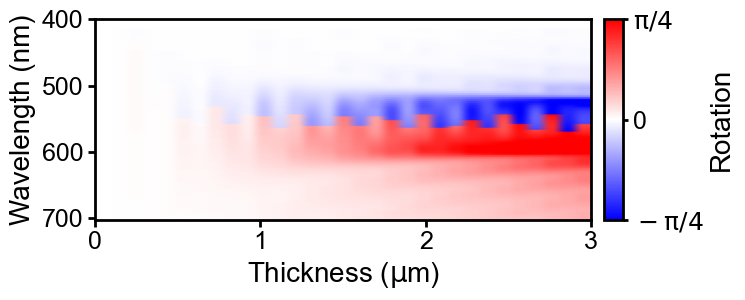

In [31]:
fo = np.load("./0.000pi.npz")
wl = fo["arr_4"]
thickness = fo["arr_5"]
S = fo["arr_2"]

rotation_img = get_rotation(S[:,:,1]/S[:,:,0],S[:,:,2]/S[:,:,0]).T
for i in range(wl.shape[0]):
    for j in range(thickness.shape[0]-1):
        add_angle = get_add_angle(rotation_img[i,j],rotation_img[i,j+1])
        rotation_img[i,j+1] += add_angle

        
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots() 
img = ax.imshow(rotation_img[:,:30],
                extent=[thickness[0], thickness[29], wl[0], wl[-1]],
                aspect=4,
                cmap="bwr",
                vmin=-45,
                vmax=45)
ax.set_xticks([0,1,2,3],[0,1,2,3],fontsize=18)
ax.set_yticks([0.4,0.5,0.6,0.7],[400,500,600,700],fontsize=18)
ax.set_xlabel(r"Thickness ($\rm \mu$m)",fontsize=20)
ax.set_ylabel("Wavelength (nm)",fontsize=20)

bwidth=2
ax.tick_params(which="major",width=bwidth,length=5)
ax.tick_params(which="minor",width=bwidth,length=3)
tk=fig.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-45,0,45])
cbar.set_ticklabels([r"$\rm -\pi/4$","0",r"$\rm \pi/4$"])
cbar.set_label(r"Rotation",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)

plt.savefig("./rotation.svg",transparent=True,bbox_inches="tight")
plt.show()

### High resolution

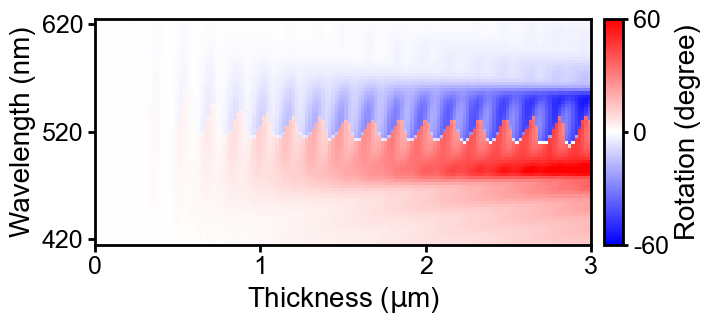

In [34]:
S = []
thickness = []
for i in range(3):
    fo = np.load("../high_res/highres%d.npz"%(i+1))
    S.append(fo["arr_2"])
    thickness.append(fo["arr_5"])
S = np.concatenate(S)
wl = fo["arr_4"]
thickness = np.concatenate(thickness)

wl_new = np.linspace(np.min(wl),np.max(wl),wl.shape[0])
rotation_img = get_rotation(S[:,:,1]/S[:,:,0],S[:,:,2]/S[:,:,0]).T
"""for i in range(wl.shape[0]):
    for j in range(thickness.shape[0]-1):
        add_angle = get_add_angle(rotation_img[i,j],rotation_img[i,j+1])
        rotation_img[i,j+1] += add_angle"""
for i in range(rotation_img.shape[1]):
    rotation_img[:,i] = np.interp(wl_new,wl[::-1],rotation_img[:,i][::-1])
        
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots() 
img = ax.imshow(rotation_img,
                extent=[thickness[0], thickness[-1], wl_new[-1]*1000, wl_new[0]*1000],
                aspect=0.0065,
                cmap="bwr",
                vmin=-60,
                vmax=60)
ax.set_ylim(415,625)
ax.set_xticks([0,1,2,3],[0,1,2,3],fontsize=18)
ax.set_yticks([420,520,620],[420,520,620],fontsize=18)
ax.set_xlabel(r"Thickness ($\rm \mu$m)",fontsize=20)
ax.set_ylabel("Wavelength (nm)",fontsize=20)

bwidth=2
ax.tick_params(which="major",width=bwidth,length=5)
ax.tick_params(which="minor",width=bwidth,length=3)
tk=fig.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

cax = fig.add_axes([ax.get_position().x1+0.02,ax.get_position().y0,0.03,ax.get_position().height])
cbar = fig.colorbar(img,cax=cax)
cbar.set_ticks([-60,0,60])
cbar.set_ticklabels(["-60","0","60"])
cbar.set_label(r"Rotation (degree)",fontsize=20)
cbar.outline.set_linewidth(2)
cbar.ax.tick_params(width=2,labelsize=18)

plt.savefig("./rotation.svg",transparent=True,bbox_inches="tight")
plt.show()